In [16]:
import help_code_ann_for_classification as help_code
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt


Task A

Epoch 1
Training cost:		0.0420986, training acc:	0.6546392
Validation cost:	0.0410067, validation acc:	0.6557971

Epoch 2
Training cost:		0.0389096, training acc:	0.6546392
Validation cost:	0.0406909, validation acc:	0.6557971

Epoch 3
Training cost:		0.0365990, training acc:	0.6721649
Validation cost:	0.0370655, validation acc:	0.6702899

Epoch 4
Training cost:		0.0300090, training acc:	0.8402062
Validation cost:	0.0270270, validation acc:	0.7934783

Epoch 5
Training cost:		0.0181009, training acc:	0.9865979
Validation cost:	0.0144102, validation acc:	0.9601449

Epoch 6
Training cost:		0.0086983, training acc:	0.9927835
Validation cost:	0.0082340, validation acc:	0.9746377

Epoch 7
Training cost:		0.0047565, training acc:	0.9979381
Validation cost:	0.0060107, validation acc:	0.9782609

Epoch 8
Training cost:		0.0029934, training acc:	0.9979381
Validation cost:	0.0042756, validation acc:	0.9818841

Epoch 9
Training cost:		0.0020796, training acc:	0.9989691
Validation cost:	0.0032252, v

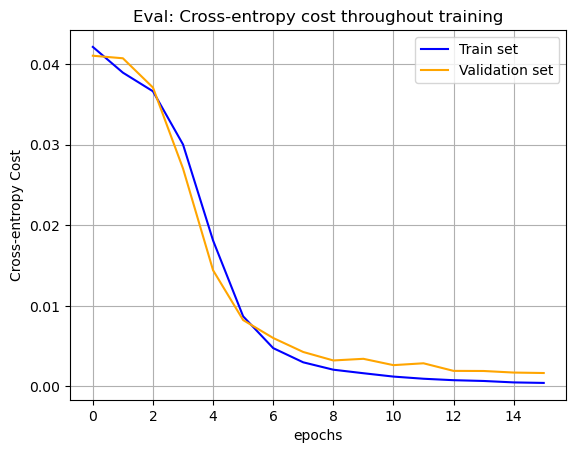

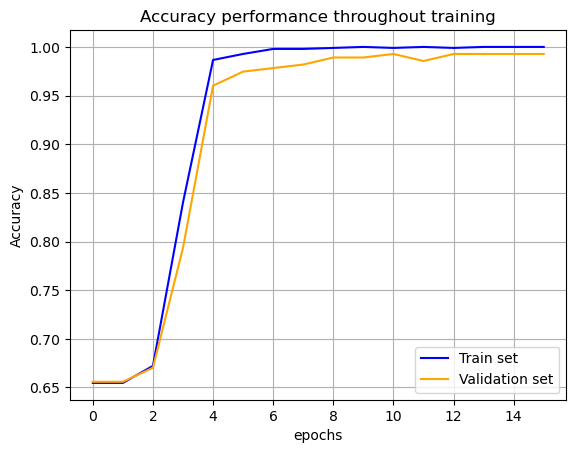

In [14]:
# (a), (b), (c)
signal_dataset = help_code.SignalDataset()
size_of_signal_dataset = len(signal_dataset)
signal_dataloader = DataLoader(dataset=signal_dataset, batch_size=1, shuffle=True)

vali_size = int(size_of_signal_dataset * 0.2)           # 20% of data
test_size = int(size_of_signal_dataset * 0.1)           # 10% of data
train_size = int(size_of_signal_dataset - (vali_size+test_size))    # Roughly 70% of data

train_data, vali_data, test_data = random_split(signal_dataset, [train_size, vali_size, test_size])

train_dataloader = DataLoader(dataset=train_data, batch_size=16, shuffle=True)
vali_dataloader = DataLoader(dataset=vali_data, batch_size=16, shuffle=True)
test_dataloader = DataLoader(dataset=test_data, batch_size=16, shuffle=True)


# (d)
model = nn.Sequential(
    nn.Linear(500, 125),
    nn.ReLU(),
    nn.Linear(125, 25),
    nn.ReLU(),
    nn.Linear(25, 2)
)


# (e)
cost_function = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.05)


def accuracy(loader, model):
    y_correct = 0
    y_total = 0
    with torch.no_grad():
        for X_pred, y_pred in loader:
            raw_y_preds = model(X_pred)
            y_class_preds = raw_y_preds.argmax(dim=1)
            y_correct += (y_class_preds == y_pred).sum().item()
            y_total += y_pred.size(0)
    
    return y_correct/y_total


# (f)
def training(iter_dataset):
    cost_list = []
    for i, (X, y) in enumerate(iter_dataset):
        optimizer.zero_grad()
        output = model(X)
        cost = cost_function(output, y)
        cost.backward()
        optimizer.step()
        
        cost_list.append(cost.item())
        
        # if i%100 == 0:
        #     print(f'minibatch: {i}, Cost: {cost.item()}')
        
    # print(cost_list)
    return cost_list


# (g) & (h)
train_cost = []
train_acc = []

vali_cost = []
vali_acc = []

for iter in range(16):
    model.train()
    train_cost.append(sum(training(train_dataloader))/train_size)
    train_acc.append(accuracy(train_dataloader, model))
    
    model.eval()
    vali_cost_iter = 0
    with torch.no_grad():
        for X, y in vali_dataloader:
            output = model(X)
            cost = cost_function(output, y)
            vali_cost_iter += cost.item()
    
    vali_cost.append(vali_cost_iter/vali_size)
    vali_acc.append(accuracy(vali_dataloader, model))
    
    print(f"Epoch {iter+1}")
    print(f"Training cost:\t\t{train_cost[-1]:.7f}, training acc:\t{train_acc[-1]:.7f}")
    print(f"Validation cost:\t{vali_cost[-1]:.7f}, validation acc:\t{vali_acc[-1]:.7f}\n")

plt.plot(train_cost, label="Train set", color="blue")
plt.plot(vali_cost, label="Validation set", color="orange")
plt.xlabel("epochs")
plt.ylabel("Cross-entropy Cost")
plt.title("Eval: Cross-entropy cost throughout training")
plt.legend()
plt.grid()
plt.show()

plt.plot(train_acc, label="Train set", color="blue")
plt.plot(vali_acc, label="Validation set", color="orange")
plt.xlabel("epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy performance throughout training")
plt.legend()
plt.grid()
plt.show()

Task B

Epoch 1
Training cost:	0.0056122, training acc:	0.6650667
Testing cost:	0.0033393, testing acc:		0.7010000

Epoch 2
Training cost:	0.0031167, training acc:	0.7490167
Testing cost:	0.0027064, testing acc:		0.7618000

Epoch 3
Training cost:	0.0026474, training acc:	0.7748833
Testing cost:	0.0024019, testing acc:		0.7844000

Epoch 4
Training cost:	0.0023674, training acc:	0.7973333
Testing cost:	0.0022140, testing acc:		0.8029000

Epoch 5
Training cost:	0.0021949, training acc:	0.8123500
Testing cost:	0.0020552, testing acc:		0.8165000

Epoch 6
Training cost:	0.0020721, training acc:	0.8180833
Testing cost:	0.0020353, testing acc:		0.8190000

Epoch 7
Training cost:	0.0019770, training acc:	0.8142333
Testing cost:	0.0019521, testing acc:		0.8191000

Epoch 8
Training cost:	0.0018951, training acc:	0.8312167
Testing cost:	0.0018659, testing acc:		0.8354000

Epoch 9
Training cost:	0.0018299, training acc:	0.8378333
Testing cost:	0.0017871, testing acc:		0.8391000

Epoch 10
Training cost:	0.00

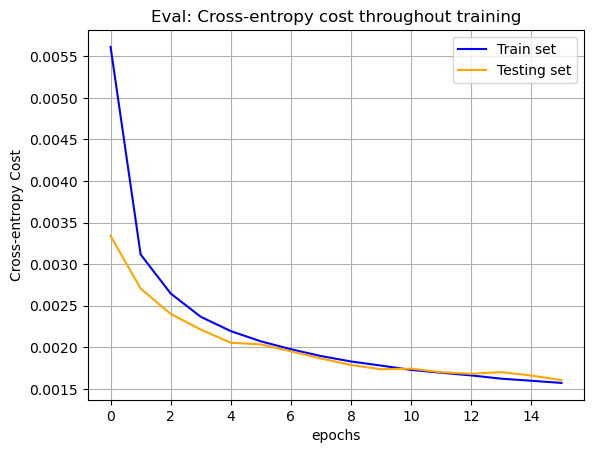

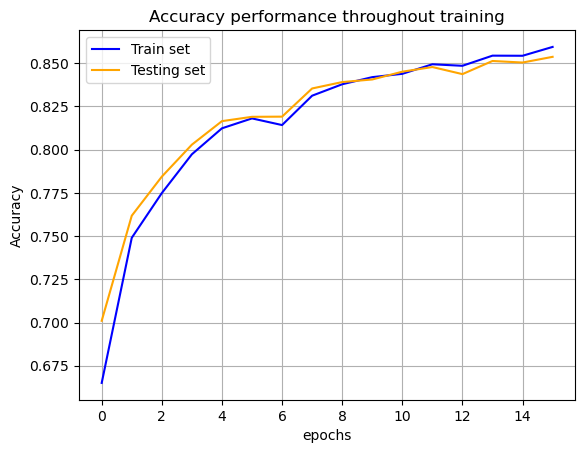

In [15]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets
from torchvision.transforms import ToTensor, Lambda, Compose
import matplotlib.pyplot as plt

training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)

model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 196),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(196, 49),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(49, 10)
)

cost_function = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.05)

batch = 256
train_dataloader_B = DataLoader(dataset=training_data, batch_size=256, shuffle=True)
test_dataloader_B = DataLoader(dataset=test_data, batch_size=256, shuffle=True)

def accuracy(loader, model):
    y_correct = 0
    y_total = 0
    with torch.no_grad():
        for X_pred, y_pred in loader:
            raw_y_preds = model(X_pred)
            y_class_preds = raw_y_preds.argmax(dim=1)
            y_correct += (y_class_preds == y_pred).sum().item()
            y_total += y_pred.size(0)
    
    return y_correct/y_total


def training(iter_dataset):
    cost_list = []
    for i, (X, y) in enumerate(iter_dataset):
        optimizer.zero_grad()
        output = model(X)
        cost = cost_function(output, y)
        cost.backward()
        optimizer.step()
        
        cost_list.append(cost.item())
        
    return cost_list


train_cost = []
train_acc = []

test_cost = []
test_acc = []

for iter in range(16):
    model.train()
    train_cost.append(sum(training(train_dataloader_B))/len(training_data))
    train_acc.append(accuracy(train_dataloader_B, model))
    
    model.eval()
    test_cost_iter = 0
    with torch.no_grad():
        for X, y in test_dataloader_B:
            output = model(X)
            cost = cost_function(output, y)
            test_cost_iter += cost.item()
    
    test_cost.append(test_cost_iter/len(test_data))
    test_acc.append(accuracy(test_dataloader_B, model))
    
    print(f"Epoch {iter+1}")
    print(f"Training cost:\t{train_cost[-1]:.7f}, training acc:\t{train_acc[-1]:.7f}")
    print(f"Testing cost:\t{test_cost[-1]:.7f}, testing acc:\t\t{test_acc[-1]:.7f}\n")

plt.plot(train_cost, label="Train set", color="blue")
plt.plot(test_cost, label="Testing set", color="orange")
plt.xlabel("epochs")
plt.ylabel("Cross-entropy Cost")
plt.title("Eval: Cross-entropy cost throughout training")
plt.legend()
plt.grid()
plt.show()

plt.plot(train_acc, label="Train set", color="blue")
plt.plot(test_acc, label="Testing set", color="orange")
plt.xlabel("epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy performance throughout training")
plt.legend()
plt.grid()
plt.show()